# Topic Modeling of Stigma-Predicted Reddit Comments

End-to-end LDA topic modeling pipeline for the stigma-positive subset of a
merged Reddit prediction CSV (default: `reddit/drug_subreddit_pred_merge.csv`).

**Pipeline**

1. Load the merged CSV and filter to rows the classifier labeled as stigma
   (`final_label == 1`).
2. Preprocess `dla_text` (comment + parent concatenated): lowercase, strip
   URLs / HTML / punctuation / digits, remove stopwords, apply length filter,
   optional WordNet lemmatization, and learn bigram phrases.
3. Build a gensim `Dictionary` + bag-of-words corpus with `filter_extremes`.
4. Select the number of topics via a `c_v` coherence sweep.
5. Train the final `LdaModel` and report perplexity / coherence.
6. Analysis

In [1]:
import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from gensim.corpora.dictionary import Dictionary
from gensim.models import Phrases
from gensim.models.phrases import Phraser
from gensim.models.ldamodel import LdaModel
from gensim.models.coherencemodel import CoherenceModel

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=DeprecationWarning)
sns.set_theme(style="whitegrid", context="talk")

for pkg in ("stopwords", "wordnet", "omw-1.4"):
    try:
        nltk.data.find(f"corpora/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)

# ---------------- Config ----------------
CSV_PATH = "../reddit/drug_subreddit_pred_merge.csv"
TEXT_COL = "dla_text"
LABEL_COL = "final_label"
STIGMA_VALUE = 1

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

NUM_TOPICS = 10          # overridden by coherence sweep unless you pin it
PASSES = 10
ITERATIONS = 200
CHUNKSIZE = 2000

# Vocabulary / phrase hyperparameters
NO_BELOW = 20            # drop tokens appearing in < NO_BELOW docs
NO_ABOVE = 0.5           # drop tokens appearing in > 50% of docs
MIN_TOKEN_LEN = 3
BIGRAM_MIN_COUNT = 20
BIGRAM_THRESHOLD = 10.0
LEMMATIZE = True

# Coherence sweep
COHERENCE_K_RANGE = list(range(4, 21, 2))  # 4, 6, ..., 20
COHERENCE_PASSES = 4                        # cheaper for sweeping
COHERENCE_ITERATIONS = 100

# Output directory for figures / CSVs / HTML
OUT_DIR = Path("../reddit/topicmodel_drug")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"CSV      : {CSV_PATH}")
print(f"OUT_DIR  : {OUT_DIR.resolve()}")
print(f"LEMMATIZE: {LEMMATIZE}")

/opt/miniconda3/envs/research-proj/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CSV      : ../reddit/drug_subreddit_pred_merge.csv
OUT_DIR  : /Users/derronli/Developer/IBEHS-4H03/reddit/topicmodel_drug
LEMMATIZE: True


## 1. Load and filter data

Load the merged CSV and keep only rows the classifier flagged as stigma
(`final_label == STIGMA_VALUE`). We also drop empty and duplicate
`dla_text` entries so repeated copy-pastes / automod boilerplate do not
dominate the topic model.

In [2]:
df_raw = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df_raw):,} rows from {CSV_PATH}")
print(f"Label distribution ({LABEL_COL}):")
print(df_raw[LABEL_COL].value_counts(dropna=False).to_string())

df = df_raw.copy()
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str).str.strip()
df = df[df[TEXT_COL].str.len() > 0]
df = df.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
print(f"\nAfter dropping empty / duplicate `{TEXT_COL}`: {len(df):,} rows")

df_stigma = df[df[LABEL_COL] == STIGMA_VALUE].reset_index(drop=True)
print(
    f"Stigma-positive subset ({LABEL_COL} == {STIGMA_VALUE}): "
    f"{len(df_stigma):,} rows "
    f"({len(df_stigma) / max(len(df), 1):.1%} of de-duplicated pool)"
)

documents = df_stigma[TEXT_COL].tolist()
df_stigma.head(2)

Loaded 20,000 rows from ../reddit/drug_subreddit_pred_merge.csv
Label distribution (final_label):
final_label
1    12828
0     7172

After dropping empty / duplicate `dla_text`: 19,887 rows
Stigma-positive subset (final_label == 1): 12,772 rows (64.2% of de-duplicated pool)


,comment_id,comment_text,parent_id,parent_text,mean_score,votes_positive,votes_total,final_label,dla_text
0,cxr0l2m,Post pics,t3_3vumz5,I just got FUCKED by my dealer\n\nLiterally.\n...,0.727617,14,14,1,Post pics\n\nI just got FUCKED by my dealer\n\...
1,ecto2xy,That would take me a while to forgive my self ...,t3_aaldt2,Fucking up on MDMA by not going to the afterpa...,0.546129,11,14,1,That would take me a while to forgive my self ...


## 2. Preprocess

In [3]:
NLTK_STOPWORDS = set(stopwords.words("english"))

CUSTOM_STOPWORDS = {
    "deleted", "removed", "http", "https", "www", "com", "edit", "amp",
    "gt", "lt", "nbsp", "like", "just", "would", "really", "people",
    "get", "got", "one", "also", "even", "thing", "things", "know",
    "think", "said", "say", "says", "well", "still", "way", "much",
    "lot", "back", "go", "going", "gonna", "want", "make", "made",
    "see", "take", "took", "yeah", "yes", "oh",
}
STOP_WORDS = NLTK_STOPWORDS | CUSTOM_STOPWORDS

URL_RE = re.compile(r"http\S+|www\.\S+")
HTML_RE = re.compile(r"&(?:amp|gt|lt|nbsp|quot|apos);")
NON_LETTER_RE = re.compile(r"[^a-z\s]")
WHITESPACE_RE = re.compile(r"\s+")

lemmatizer = WordNetLemmatizer() if LEMMATIZE else None


def tokenize(text: str) -> list[str]:
    """Lowercase, strip URLs/HTML/punctuation, drop stopwords, optional lemmatize."""
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = HTML_RE.sub(" ", text)
    text = NON_LETTER_RE.sub(" ", text)
    text = WHITESPACE_RE.sub(" ", text).strip()

    tokens = [t for t in text.split() if len(t) >= MIN_TOKEN_LEN and t not in STOP_WORDS]
    if lemmatizer is not None:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
        tokens = [t for t in tokens if t not in STOP_WORDS]
    return tokens


tokenized_docs = [tokenize(doc) for doc in tqdm(documents, desc="Tokenizing")]

bigram = Phrases(tokenized_docs, min_count=BIGRAM_MIN_COUNT, threshold=BIGRAM_THRESHOLD)
bigram_mod = Phraser(bigram)
processed_docs = [bigram_mod[doc] for doc in tqdm(tokenized_docs, desc="Applying bigrams")]

doc_lengths = np.array([len(d) for d in processed_docs])
nonempty_mask = doc_lengths > 0
print(
    f"Tokenized {len(processed_docs):,} documents | "
    f"non-empty: {int(nonempty_mask.sum()):,} | "
    f"mean tokens/doc: {doc_lengths[nonempty_mask].mean():.1f} | "
    f"median: {int(np.median(doc_lengths[nonempty_mask]))} | "
    f"max: {int(doc_lengths.max())}"
)

processed_docs = [d for d, keep in zip(processed_docs, nonempty_mask) if keep]
df_stigma = df_stigma.loc[nonempty_mask].reset_index(drop=True)
documents = df_stigma[TEXT_COL].tolist()
print(f"Retained {len(processed_docs):,} non-empty documents for modeling.")

Applying bigrams: 100%|██████████| 12772/12772 [00:00<00:00, 84657.76it/s]

Tokenized 12,772 documents | non-empty: 12,749 | mean tokens/doc: 52.1 | median: 31 | max: 2011
Retained 12,749 non-empty documents for modeling.


## 3. Dictionary and bag-of-words corpus


In [4]:
dictionary = Dictionary(processed_docs)
print(f"Raw vocabulary size: {len(dictionary):,}")

dictionary.filter_extremes(no_below=NO_BELOW, no_above=NO_ABOVE)
dictionary.compactify()
print(
    f"After filter_extremes(no_below={NO_BELOW}, no_above={NO_ABOVE}): "
    f"{len(dictionary):,} tokens"
)

corpus = [dictionary.doc2bow(doc) for doc in processed_docs]
bow_lengths = np.array([sum(c for _, c in doc) for doc in corpus])
print(
    f"Corpus size: {len(corpus):,} docs | "
    f"mean BoW length: {bow_lengths.mean():.1f} | "
    f"median: {int(np.median(bow_lengths))} | "
    f"0-length docs: {int((bow_lengths == 0).sum())}"
)

Raw vocabulary size: 26,136
After filter_extremes(no_below=20, no_above=0.5): 3,681 tokens
Corpus size: 12,749 docs | mean BoW length: 45.9 | median: 27 | 0-length docs: 26


## 4. Choose the number of topics

Sweep `K` across `COHERENCE_K_RANGE`, train a cheap LDA at each `K`, and
score it with the `c_v` coherence. We keep the `K`
with the highest coherence as `BEST_K`.

Coherence sweep:  11%|█         | 1/9 [00:06<00:54,  6.77s/it]

  k=  4  c_v=0.4184


Coherence sweep:  22%|██▏       | 2/9 [00:13<00:46,  6.65s/it]

  k=  6  c_v=0.4690


Coherence sweep:  33%|███▎      | 3/9 [00:19<00:38,  6.49s/it]

...

  k= 16  c_v=0.4362


Coherence sweep:  89%|████████▉ | 8/9 [00:52<00:06,  6.54s/it]

  k= 18  c_v=0.4330


Coherence sweep: 100%|██████████| 9/9 [00:59<00:00,  6.56s/it]

  k= 20  c_v=0.4309

Best K by c_v coherence: 6


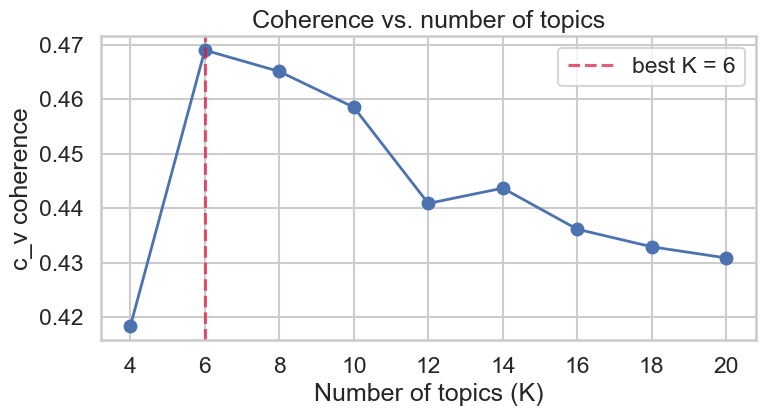

In [5]:
coherence_records = []
for k in tqdm(COHERENCE_K_RANGE, desc="Coherence sweep"):
    lda_k = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=COHERENCE_PASSES,
        iterations=COHERENCE_ITERATIONS,
        chunksize=CHUNKSIZE,
        random_state=RANDOM_STATE,
        alpha="auto",
        eta="auto",
        eval_every=None,
    )
    cm = CoherenceModel(
        model=lda_k,
        texts=processed_docs,
        dictionary=dictionary,
        coherence="c_v",
    )
    score = cm.get_coherence()
    coherence_records.append({"k": k, "coherence_c_v": score})
    print(f"  k={k:3d}  c_v={score:.4f}")

coherence_df = pd.DataFrame(coherence_records)
coherence_df.to_csv(OUT_DIR / "coherence_vs_k.csv", index=False)

BEST_K = int(coherence_df.loc[coherence_df["coherence_c_v"].idxmax(), "k"])
print(f"\nBest K by c_v coherence: {BEST_K}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(coherence_df["k"], coherence_df["coherence_c_v"], marker="o", linewidth=2)
ax.axvline(BEST_K, color="crimson", linestyle="--", alpha=0.7, label=f"best K = {BEST_K}")
ax.set_xlabel("Number of topics (K)")
ax.set_ylabel("c_v coherence")
ax.set_title("Coherence vs. number of topics")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "coherence_vs_k.png", dpi=150)
plt.show()

NUM_TOPICS = BEST_K

## 5. Train the final LDA model

Train with more passes / iterations at the selected `K`. We use
`alpha="auto"` and `eta="auto"` so gensim learns asymmetric priors from
the data, and we report both `log_perplexity` (held-out fit) and `c_v`
coherence (topic interpretability).

In [6]:
print(f"Training final LDA with K={NUM_TOPICS}, passes={PASSES}, iterations={ITERATIONS}...")
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    passes=PASSES,
    iterations=ITERATIONS,
    chunksize=CHUNKSIZE,
    random_state=RANDOM_STATE,
    alpha="auto",
    eta="auto",
    eval_every=None,
)

log_perplexity = lda_model.log_perplexity(corpus)
perplexity = float(np.exp2(-log_perplexity))

final_coherence_c_v = CoherenceModel(
    model=lda_model,
    texts=processed_docs,
    dictionary=dictionary,
    coherence="c_v",
).get_coherence()

final_coherence_umass = CoherenceModel(
    model=lda_model,
    corpus=corpus,
    dictionary=dictionary,
    coherence="u_mass",
).get_coherence()

print(f"log_perplexity   : {log_perplexity:.4f}")
print(f"perplexity       : {perplexity:.2f}")
print(f"coherence (c_v)  : {final_coherence_c_v:.4f}")
print(f"coherence (u_mass): {final_coherence_umass:.4f}")

lda_model.save(str(OUT_DIR / "lda_model.gensim"))
dictionary.save(str(OUT_DIR / "dictionary.gensim"))
print(f"\nSaved model + dictionary to {OUT_DIR.resolve()}")

Training final LDA with K=6, passes=10, iterations=200...
log_perplexity   : -7.2878
perplexity       : 156.26
coherence (c_v)  : 0.4692
coherence (u_mass): -2.5847

Saved model + dictionary to /Users/derronli/Developer/IBEHS-4H03/reddit/topicmodel_drug


## 6. Analysis

### 6a. Top-words table

In [7]:
TOP_N = 10

top_words_rows = []
for t in range(NUM_TOPICS):
    top = lda_model.show_topic(t, topn=TOP_N)
    top_words_rows.append({
        "topic": t,
        "top_words": ", ".join(w for w, _ in top),
        **{f"w{i+1}": w for i, (w, _) in enumerate(top)},
        **{f"p{i+1}": round(float(p), 4) for i, (_, p) in enumerate(top)},
    })

top_words_df = pd.DataFrame(top_words_rows)
top_words_df.to_csv(OUT_DIR / "top_words.csv", index=False)
display(top_words_df[["topic", "top_words"]])

,topic,top_words
0,0,"life, time, feel, year, day, addiction, help, ..."
1,1,"weed, alcohol, smoke, smoking, drink, day, dri..."
2,2,"time, friend, shit, could, fuck, felt, around,..."
3,3,"drug, question_concern, drug_wiki, subreddit_m..."
4,4,"drug, feel, meth, high, withdrawal, day, takin..."
5,5,"drug, use, addiction, someone, could, mean, ne..."


### 6b. Per-topic top-word bar charts

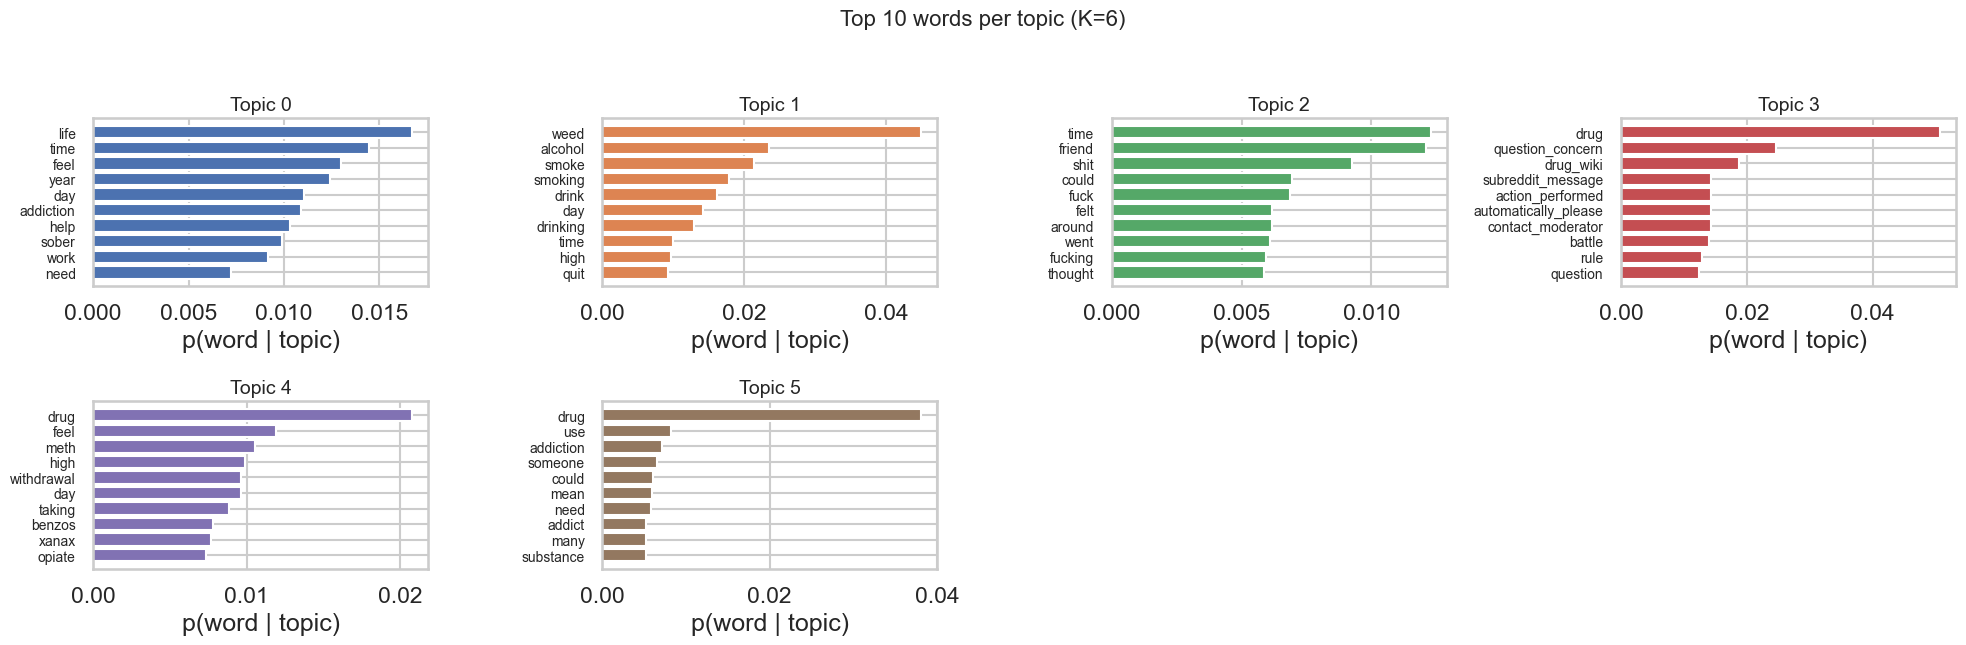

In [8]:
n_cols = min(4, NUM_TOPICS)
n_rows = int(np.ceil(NUM_TOPICS / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.2 * n_rows))
axes = np.array(axes).reshape(-1)

for t in range(NUM_TOPICS):
    ax = axes[t]
    top = lda_model.show_topic(t, topn=TOP_N)
    words = [w for w, _ in top][::-1]
    probs = [p for _, p in top][::-1]
    ax.barh(words, probs, color=sns.color_palette("deep", NUM_TOPICS)[t % 10])
    ax.set_title(f"Topic {t}", fontsize=14)
    ax.set_xlabel("p(word | topic)")
    ax.tick_params(axis="y", labelsize=10)

for j in range(NUM_TOPICS, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Top {TOP_N} words per topic (K={NUM_TOPICS})", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "topic_bars.png", dpi=150, bbox_inches="tight")
plt.show()

### 6c. Word clouds per topic

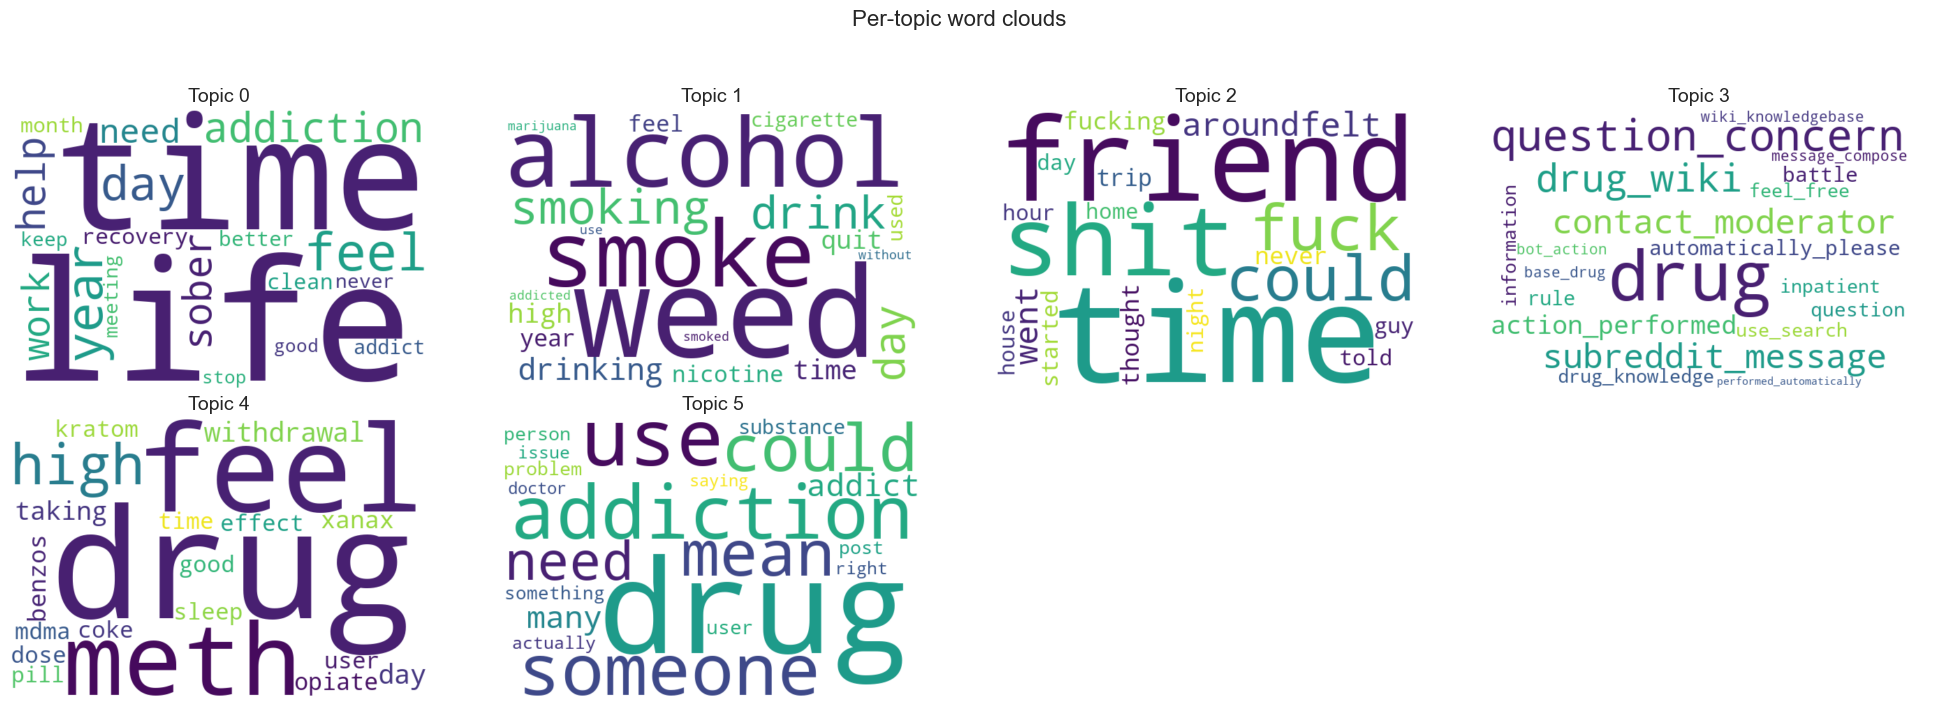

In [16]:
from wordcloud import WordCloud

WC_TOP_N = 20

n_cols = min(4, NUM_TOPICS)
n_rows = int(np.ceil(NUM_TOPICS / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for t in range(NUM_TOPICS):
    freqs = dict(lda_model.show_topic(t, topn=WC_TOP_N))
    wc = WordCloud(
        width=600,
        height=400,
        background_color="white",
        prefer_horizontal=0.95,
        random_state=RANDOM_STATE,
        colormap="viridis",
    ).generate_from_frequencies(freqs)

    axes[t].imshow(wc, interpolation="bilinear")
    axes[t].set_title(f"Topic {t}", fontsize=14)
    axes[t].axis("off")

for j in range(NUM_TOPICS, len(axes)):
    axes[j].axis("off")

fig.suptitle("Per-topic word clouds", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "topic_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

### 6d. Topic prevalence

Average per-document topic probability across the stigma-positive corpus
(i.e. expected share of the corpus assigned to each topic).

Inferring doc-topic distributions: 100%|██████████| 12749/12749 [00:00<00:00, 12948.76it/s]


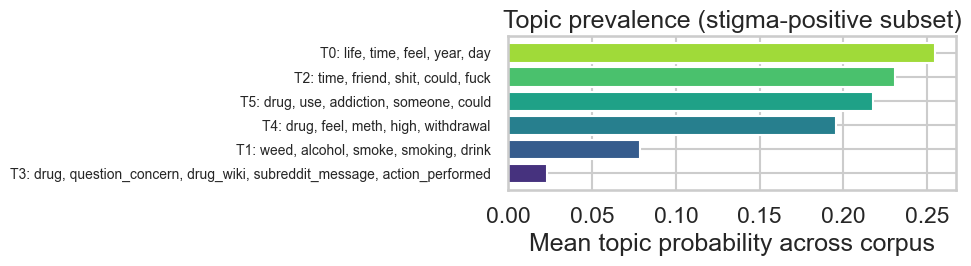

,topic,prevalence,top_words
0,0,0.254412,"life, time, feel, year, day, addiction, help, ..."
1,2,0.230560,"time, friend, shit, could, fuck, felt, around,..."
2,5,0.217691,"drug, use, addiction, someone, could, mean, ne..."
3,4,0.195548,"drug, feel, meth, high, withdrawal, day, takin..."
4,1,0.078489,"weed, alcohol, smoke, smoking, drink, day, dri..."
5,3,0.023299,"drug, question_concern, drug_wiki, subreddit_m..."


In [17]:
doc_topic_matrix = np.zeros((len(corpus), NUM_TOPICS), dtype=np.float32)
for i, bow in enumerate(tqdm(corpus, desc="Inferring doc-topic distributions")):
    for t, p in lda_model.get_document_topics(bow, minimum_probability=0.0):
        doc_topic_matrix[i, t] = p

prevalence = doc_topic_matrix.mean(axis=0)
prevalence = prevalence / prevalence.sum()
order = np.argsort(prevalence)[::-1]

prevalence_df = pd.DataFrame({
    "topic": np.arange(NUM_TOPICS),
    "prevalence": prevalence,
    "top_words": [", ".join(w for w, _ in lda_model.show_topic(t, topn=TOP_N)) for t in range(NUM_TOPICS)],
}).sort_values("prevalence", ascending=False).reset_index(drop=True)
prevalence_df.to_csv(OUT_DIR / "topic_prevalence.csv", index=False)

fig, ax = plt.subplots(figsize=(10, max(3, 0.45 * NUM_TOPICS)))
labels = [f"T{t}: {', '.join(w for w, _ in lda_model.show_topic(t, topn=5))}" for t in order]
ax.barh(range(len(order)), prevalence[order][::-1], color=sns.color_palette("viridis", NUM_TOPICS))
ax.set_yticks(range(len(order)))
ax.set_yticklabels(labels[::-1], fontsize=10)
ax.set_xlabel("Mean topic probability across corpus")
ax.set_title("Topic prevalence (stigma-positive subset)")
fig.tight_layout()
fig.savefig(OUT_DIR / "topic_prevalence.png", dpi=150, bbox_inches="tight")
plt.show()

display(prevalence_df.head(NUM_TOPICS))

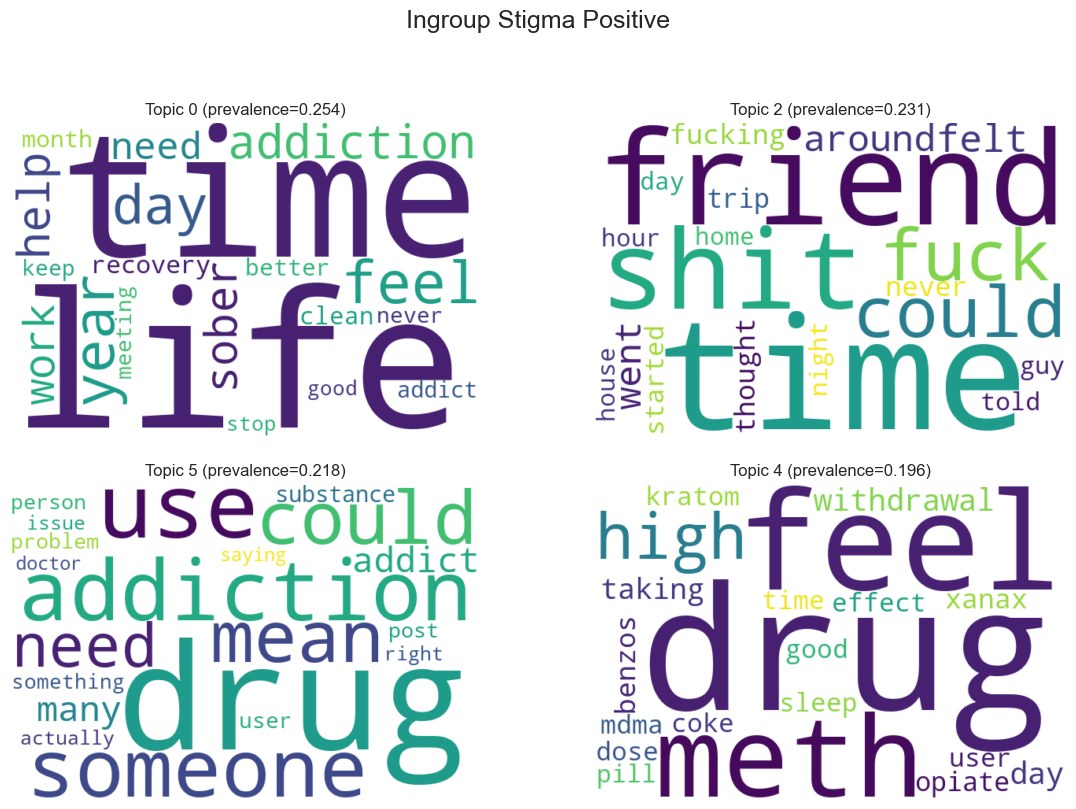

In [22]:
# 6d-extra. Word clouds for top-4 most prevalent topics (2x2)
TOP4_WC_TOP_N = 20

top4_topics = prevalence_df.head(4)["topic"].astype(int).tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.reshape(-1)

for ax, t in zip(axes, top4_topics):
    freqs = dict(lda_model.show_topic(t, topn=TOP4_WC_TOP_N))
    wc = WordCloud(
        width=600,
        height=400,
        background_color="white",
        prefer_horizontal=0.95,
        random_state=RANDOM_STATE,
        colormap="viridis",
    ).generate_from_frequencies(freqs)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Topic {t} (prevalence={prevalence[t]:.3f})", fontsize=12)
    ax.axis("off")

for j in range(len(top4_topics), 4):
    axes[j].axis("off")

fig.suptitle("Ingroup Stigma Positive", fontsize=18, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "topic_wordclouds_top4_prevalence.png", dpi=150, bbox_inches="tight")
plt.show()

### 6e. Dominant topic per document

Assign each document its argmax topic, then count how many documents fall
into each topic and the mean confidence (top-topic probability).

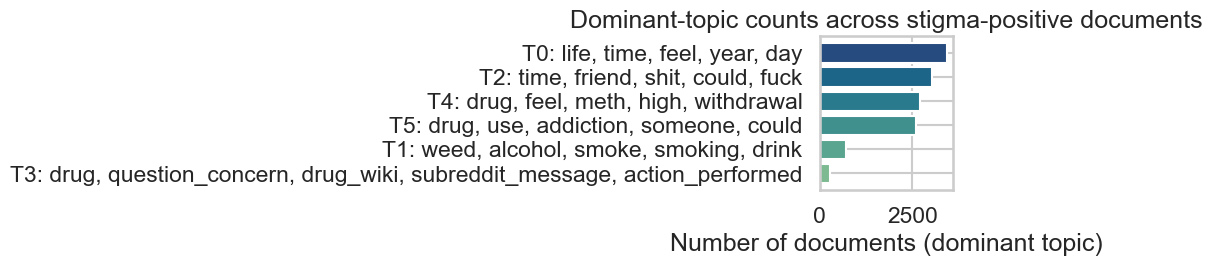

,dominant_topic,n_docs,pct_docs,mean_top_prob,top_words
0,0,3433,0.269276,0.615595,"life, time, feel, year, day, addiction, help, ..."
1,2,3030,0.237666,0.604162,"time, friend, shit, could, fuck, felt, around,..."
2,4,2711,0.212644,0.594184,"drug, feel, meth, high, withdrawal, day, takin..."
3,5,2610,0.204722,0.584612,"drug, use, addiction, someone, could, mean, ne..."
4,1,700,0.054906,0.526758,"weed, alcohol, smoke, smoking, drink, day, dri..."
5,3,265,0.020786,0.830662,"drug, question_concern, drug_wiki, subreddit_m..."


In [11]:
dominant_topic = doc_topic_matrix.argmax(axis=1)
dominant_prob = doc_topic_matrix.max(axis=1)

df_docs = df_stigma.copy()
df_docs["dominant_topic"] = dominant_topic
df_docs["dominant_topic_prob"] = dominant_prob
df_docs[["comment_id", TEXT_COL, "dominant_topic", "dominant_topic_prob"]].to_csv(
    OUT_DIR / "doc_dominant_topic.csv", index=False
)

summary = (
    df_docs.groupby("dominant_topic")
    .agg(
        n_docs=("dominant_topic", "size"),
        mean_top_prob=("dominant_topic_prob", "mean"),
    )
    .reset_index()
)
summary["pct_docs"] = summary["n_docs"] / summary["n_docs"].sum()
summary["top_words"] = summary["dominant_topic"].map(
    lambda t: ", ".join(w for w, _ in lda_model.show_topic(int(t), topn=TOP_N))
)
summary = summary.sort_values("n_docs", ascending=False).reset_index(drop=True)
summary.to_csv(OUT_DIR / "dominant_topic_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(10, max(3, 0.45 * NUM_TOPICS)))
plot_df = summary.sort_values("n_docs", ascending=True)
labels = [f"T{int(t)}: {', '.join(w for w, _ in lda_model.show_topic(int(t), topn=5))}" for t in plot_df["dominant_topic"]]
ax.barh(labels, plot_df["n_docs"], color=sns.color_palette("crest", NUM_TOPICS))
ax.set_xlabel("Number of documents (dominant topic)")
ax.set_title("Dominant-topic counts across stigma-positive documents")
fig.tight_layout()
fig.savefig(OUT_DIR / "dominant_topic_counts.png", dpi=150, bbox_inches="tight")
plt.show()

display(summary[["dominant_topic", "n_docs", "pct_docs", "mean_top_prob", "top_words"]])

### 6f. Representative documents per topic

In [12]:
REP_DOCS_PER_TOPIC = 3
REP_SNIPPET_CHARS = 400

rep_rows = []
for t in range(NUM_TOPICS):
    top_idx = np.argsort(doc_topic_matrix[:, t])[::-1][:REP_DOCS_PER_TOPIC]
    top_words = ", ".join(w for w, _ in lda_model.show_topic(t, topn=TOP_N))
    print(f"\n=== Topic {t} === [{top_words}]")
    for rank, idx in enumerate(top_idx, 1):
        prob = float(doc_topic_matrix[idx, t])
        text = documents[idx].replace("\n", " ").strip()
        snippet = text[:REP_SNIPPET_CHARS] + ("..." if len(text) > REP_SNIPPET_CHARS else "")
        cid = df_stigma.iloc[idx].get("comment_id", "")
        print(f"  [{rank}] p={prob:.3f}  comment_id={cid}")
        print(f"      {snippet}")
        rep_rows.append({
            "topic": t,
            "rank": rank,
            "prob": prob,
            "comment_id": cid,
            "text": text,
        })

pd.DataFrame(rep_rows).to_csv(OUT_DIR / "representative_docs.csv", index=False)


=== Topic 0 === [life, time, feel, year, day, addiction, help, sober, work, need]
  [1] p=0.988  comment_id=iy3aeex
      Thank you 💕  First, congratulations on 51 days! That’s no small feat! Early sobriety is the hardest. It does get easier over time. I was an emotional mess when I first got sober. The emotional highs and lows were maddening. But, I needed to learn how to face life on life’s terms, without using alcohol to numb my feelings. That took time and how much time is different for everyone. But, it will pas...
  [2] p=0.987  comment_id=gza2n9u
      There is absolutely nothing wrong with "okayish". I feel this way fairly often these days and I am grateful for it. Before I was sober, nothing was okay. Everyday was a struggle I hardly wanted to fight. When I think about how things are today, I don't have to use those words. I can say things are ok and I mean it. Ok to me means content and that is a wonderful thing. I love being content.  As lon...
  [3] p=0.987  comment_id=djq

### 6g. Interactive pyLDAvis

Intertopic-distance map (MDS projection) + relevance-ranked term bars.
Saved as a standalone HTML file so it can be shared or embedded in a
report.

In [13]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)
pyLDAvis.save_html(vis, str(OUT_DIR / "ldavis.html"))
print(f"Saved interactive visualization to {OUT_DIR / 'ldavis.html'}")
vis

Saved interactive visualization to ../reddit/topicmodel_drug/ldavis.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.109411  0.079276       1        1  29.732167
1      0.107840 -0.215288       2        1   7.265365
2      0.099826  0.093498       3        1  25.933803
3     -0.412138 -0.019689       4        1   1.756220
4      0.076877 -0.068768       5        1  16.846641
5      0.018184  0.130971       6        1  18.465803, topic_info=         Term         Freq        Total Category  logprob  loglift
11       drug  7753.000000  7753.000000  Default  30.0000  30.0000
309      weed  2061.000000  2061.000000  Default  29.0000  29.0000
282   alcohol  1923.000000  1923.000000  Default  28.0000  28.0000
241     smoke   942.000000   942.000000  Default  27.0000  27.0000
105       day  4151.000000  4151.000000  Default  26.0000  26.0000
..        ...          ...          ...      ...      ...      ...
256      tell   351.464567  1281.537755   Topic6  -5.7272   0.3955
283  anything   370.024481  1712.622003   Topic6  -5.6758   0.1570
178      look   329.237486   977.039562   Topic6  -5.7926   0.6015
443      help   383.454282  2496.267035   Topic6  -5.6401  -0.1841
235      shit   349.096685  2285.640203   Topic6  -5.7340  -0.1898

[442 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
2911      2  0.986518  accountable
281       2  0.004376         acid
281       3  0.820430         acid
281       4  0.004376         acid
281       5  0.170649         acid
...     ...       ...          ...
477       3  0.044208         year
477       5  0.054631         year
477       6  0.009345         year
3593      2  0.971886    young_age
2187      3  0.992115         zoom

[965 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6])

## 7. Reported metrics and artifacts

In [14]:
summary_metrics = {
    "csv_path": str(CSV_PATH),
    "text_column": TEXT_COL,
    "label_column": LABEL_COL,
    "stigma_value": STIGMA_VALUE,
    "n_documents_modeled": len(corpus),
    "vocab_size": len(dictionary),
    "num_topics_K": NUM_TOPICS,
    "coherence_c_v": round(float(final_coherence_c_v), 4),
    "coherence_u_mass": round(float(final_coherence_umass), 4),
    "log_perplexity": round(float(log_perplexity), 4),
    "perplexity": round(float(perplexity), 2),
    "passes": PASSES,
    "iterations": ITERATIONS,
    "no_below": NO_BELOW,
    "no_above": NO_ABOVE,
    "random_state": RANDOM_STATE,
    "lemmatize": LEMMATIZE,
}
summary_df = pd.DataFrame([summary_metrics]).T.rename(columns={0: "value"})
summary_df.to_csv(OUT_DIR / "run_summary.csv")
print("Run summary:")
for k, v in summary_metrics.items():
    print(f"  {k:22s} {v}")

print("\nArtifacts written to", OUT_DIR.resolve())
for p in sorted(OUT_DIR.iterdir()):
    print(" -", p.name)

Run summary:
  csv_path               ../reddit/drug_subreddit_pred_merge.csv
  text_column            dla_text
  label_column           final_label
  stigma_value           1
  n_documents_modeled    12749
  vocab_size             3681
  num_topics_K           6
  coherence_c_v          0.4692
  coherence_u_mass       -2.5847
  log_perplexity         -7.2878
  perplexity             156.26
  passes                 10
  iterations             200
  no_below               20
  no_above               0.5
  random_state           42
  lemmatize              True

Artifacts written to /Users/derronli/Developer/IBEHS-4H03/reddit/topicmodel_drug
 - coherence_vs_k.csv
 - coherence_vs_k.png
 - dictionary.gensim
 - doc_dominant_topic.csv
 - dominant_topic_counts.png
 - dominant_topic_summary.csv
 - lda_model.gensim
 - lda_model.gensim.expElogbeta.npy
 - lda_model.gensim.id2word
 - lda_model.gensim.state
 - ldavis.html
 - representative_docs.csv
 - run_summary.csv
 - top_words.csv
 - topic_bars.